In [22]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np
import json
import re
from pathlib import Path
from typing import List, Dict
from tbparse import SummaryReader

In [23]:
project_root = Path.cwd()
if not (project_root / "runs").exists():
    project_root = project_root.parent

### BP experiments (from bp_only notebook)


In [24]:
BP_EXPERIMENT_NAMES = [
    "experiment_only_backprop_20260604_090527",
    "experiment_only_backprop_20260604_090543",
    "experiment_only_backprop_20260604_090556",
]
BP_EXPERIMENT_DIRS = [project_root / "runs" / exp for exp in BP_EXPERIMENT_NAMES]

bp_experiments = []
for exp_dir in BP_EXPERIMENT_DIRS:
    for subdir in exp_dir.iterdir():
        if subdir.is_dir() and not subdir.name.startswith("logs"):
            bp_experiments.append(str(subdir.relative_to(project_root)))

bp_results = [
    str((project_root / "results" / e.split("\\")[2]).relative_to(project_root)) + ".json" for e in bp_experiments
]
bp_experiments

['runs\\experiment_only_backprop_20260604_090527\\bp_cnn_cifar100_proj2048_20260604_095348_seed1231',
 'runs\\experiment_only_backprop_20260604_090527\\bp_cnn_cifar10_proj2048_20260604_093058_seed1231',
 'runs\\experiment_only_backprop_20260604_090527\\bp_cnn_fashionmnist_proj2048_20260604_091754_seed1231',
 'runs\\experiment_only_backprop_20260604_090527\\bp_cnn_mnist_proj2048_20260604_090700_seed1231',
 'runs\\experiment_only_backprop_20260604_090543\\bp_cnn_cifar100_proj2048_20260604_110305_seed3845',
 'runs\\experiment_only_backprop_20260604_090543\\bp_cnn_cifar10_proj2048_20260604_104028_seed3845',
 'runs\\experiment_only_backprop_20260604_090543\\bp_cnn_fashionmnist_proj2048_20260604_102801_seed3845',
 'runs\\experiment_only_backprop_20260604_090543\\bp_cnn_mnist_proj2048_20260604_101646_seed3845',
 'runs\\experiment_only_backprop_20260604_090556\\bp_cnn_cifar100_proj2048_20260604_121230_seed92389',
 'runs\\experiment_only_backprop_20260604_090556\\bp_cnn_cifar10_proj2048_2026060

## MF+AD / MF+DD experiments (from acc_comparison notebook)


In [25]:
MF_EXPERIMENT_NAMES = [
    "experiment_all_20260528_114458",
    "experiment_all_20260528_114510",
    "experiment_all_20260528_114532",
]
MF_EXPERIMENT_DIRS = [project_root / "runs" / exp for exp in MF_EXPERIMENT_NAMES]

mf_experiments = []
for exp_dir in MF_EXPERIMENT_DIRS:
    for subdir in exp_dir.iterdir():
        if subdir.is_dir() and not subdir.name.startswith("logs"):
            mf_experiments.append(str(subdir.relative_to(project_root)))

mf_results = [
    str((project_root / "results" / e.split("\\")[2]).relative_to(project_root)) + ".json" for e in mf_experiments
]
mf_experiments[:4]

['runs\\experiment_all_20260528_114458\\bp_autodiff_cnn_cifar100_20260528_131519_seed155',
 'runs\\experiment_all_20260528_114458\\bp_autodiff_cnn_cifar10_20260528_123132_seed155',
 'runs\\experiment_all_20260528_114458\\bp_autodiff_cnn_fashionmnist_20260528_120603_seed155',
 'runs\\experiment_all_20260528_114458\\bp_autodiff_cnn_mnist_20260528_114616_seed155']

## Training time

Derived from TensorBoard wall-clock timestamps: `max(wall_clock) - min(wall_clock)` per run directory.


In [26]:
bp_tb_dfs: List[pd.DataFrame] = [
    SummaryReader(exp_dir, extra_columns={"wall_time", "dir_name"}).scalars for exp_dir in BP_EXPERIMENT_DIRS
]
df_bp = pd.concat(bp_tb_dfs, ignore_index=True)
df_bp = df_bp.assign(
    wall_clock=pd.to_datetime(df_bp["wall_time"], unit="s", utc=True),
    architecture=df_bp["dir_name"].str.extract(r"_(cnn|mlp)_")[0],
    dataset=df_bp["dir_name"].str.extract(r"_(mnist|fashionmnist|cifar\d+)_")[0],
    seed=df_bp["dir_name"].str.extract(r"_seed(\d+)")[0].astype(int),
).drop(columns=["wall_time"])

print(df_bp.shape)
df_bp.head(2)

(9600, 8)


,step,tag,value,dir_name,wall_clock,architecture,dataset,seed
0,1,backprop/bp/acc/train,0.152156,bp_cnn_cifar100_proj2048_20260604_095348_seed1231,2026-06-04 07:54:05.701327324+00:00,cnn,cifar100,1231
1,2,backprop/bp/acc/train,0.275089,bp_cnn_cifar100_proj2048_20260604_095348_seed1231,2026-06-04 07:54:12.121021986+00:00,cnn,cifar100,1231


In [27]:
mf_tb_dfs: List[pd.DataFrame] = [
    SummaryReader(exp_dir, extra_columns={"wall_time", "dir_name"}).scalars for exp_dir in MF_EXPERIMENT_DIRS
]
df_mf = pd.concat(mf_tb_dfs, ignore_index=True)
df_mf = df_mf.assign(
    wall_clock=pd.to_datetime(df_mf["wall_time"], unit="s", utc=True),
    architecture=df_mf["dir_name"].str.extract(r"_(cnn|mlp)_")[0],
    dataset=df_mf["dir_name"].str.extract(r"_(mnist|fashionmnist|cifar\d+)_")[0],
    seed=df_mf["dir_name"].str.extract(r"_seed(\d+)")[0].astype(int),
).drop(columns=["wall_time"])

print(df_mf.shape)
df_mf.head(2)

(196800, 8)


,step,tag,value,dir_name,wall_clock,architecture,dataset,seed
0,1,autodiff/layer_acc/layer_0/train,0.012200,bp_autodiff_cnn_cifar100_20260528_131519_seed155,2026-05-28 11:15:37.269617319+00:00,cnn,cifar100,155
1,2,autodiff/layer_acc/layer_0/train,0.016289,bp_autodiff_cnn_cifar100_20260528_131519_seed155,2026-05-28 11:15:43.609385014+00:00,cnn,cifar100,155


In [28]:
def compute_timing(df: pd.DataFrame, phase: str) -> pd.DataFrame:
    rows = []
    for dir_name, grp in df.groupby("dir_name"):
        duration_min = (grp["wall_clock"].max() - grp["wall_clock"].min()).total_seconds() / 60
        r = grp.iloc[0]
        rows.append(
            dict(
                method=phase,
                arch=r["architecture"],
                dataset=r["dataset"],
                seed=r["seed"],
                duration_min=duration_min,
            )
        )
    return pd.DataFrame(rows)


# CNN BP timing: from bp_only runs
bp_timing = compute_timing(df_bp, phase="bp")


# MF+AD, MF+DD, and MLP BP timing: split by tag prefix from mf runs
def phase_of(tag: str) -> str:
    prefix = tag.split("/")[0]
    return {"backprop": "bp", "autodiff": "mf_ad", "dd": "mf_dd"}.get(prefix, None)


df_mf = df_mf.assign(phase=df_mf["tag"].map(phase_of))

mf_timing_rows = []
for (dir_name, phase), grp in df_mf.groupby(["dir_name", "phase"]):
    if phase is None:
        continue
    arch = grp.iloc[0]["architecture"]
    # CNN BP timing comes from bp_only; skip the backprop phase in mf runs for cnn
    if phase == "bp" and arch == "cnn":
        continue
    duration_min = (grp["wall_clock"].max() - grp["wall_clock"].min()).total_seconds() / 60
    r = grp.iloc[0]
    mf_timing_rows.append(
        dict(
            method=phase,
            arch=arch,
            dataset=r["dataset"],
            seed=r["seed"],
            duration_min=duration_min,
        )
    )
mf_timing = pd.DataFrame(mf_timing_rows)

timing_raw = pd.concat([bp_timing, mf_timing], ignore_index=True)
timing_agg = timing_raw.groupby(["arch", "method", "dataset"])["duration_min"].agg(mean="mean", std="std").reset_index()
timing_raw.pivot_table(index=["arch", "method", "dataset"], columns="seed", values="duration_min").sort_index()

seed                         155         200        1231       3845     \
arch method dataset                                                      
cnn  bp     cifar10              NaN         NaN  20.976018  20.928824   
            cifar100             NaN         NaN  21.297412  21.318247   
            fashionmnist         NaN         NaN  11.432872  10.808327   
            mnist                NaN         NaN   9.420063   8.940096   
     mf_ad  cifar10        20.841860   21.006223        NaN        NaN   
            cifar100       21.065105   21.208130        NaN        NaN   
            fashionmnist   11.754428   11.587209        NaN        NaN   
            mnist           9.246970    9.210789        NaN        NaN   
     mf_dd  cifar10       123.400689  122.945401        NaN        NaN   
            cifar100      129.681602  129.435548        NaN        NaN   
            fashionmnist   40.654742   40.404855        NaN        NaN   
            mnist          23.113594   22.838177        NaN        NaN   
mlp  bp     cifar10         9.045943   10.134561        NaN        NaN   
            cifar100        9.276451    9.497632        NaN        NaN   
            fashionmnist    7.584727    7.167079        NaN        NaN   
            mnist           7.342680    7.060912        NaN        NaN   
     mf_ad  cifar10         9.205406   10.228624        NaN        NaN   
            cifar100        9.285126    9.686497        NaN        NaN   
            fashionmnist    7.789723    7.452677        NaN        NaN   
            mnist           7.637980    7.232563        NaN        NaN   
     mf_dd  cifar10        26.234117   25.667986        NaN        NaN   
            cifar100       26.876228   26.392568        NaN        NaN   
            fashionmnist    9.492419    9.380120        NaN        NaN   
            mnist           8.238325    8.004620        NaN        NaN   

seed                        92389       1231123  
arch method dataset                              
cnn  bp     cifar10       21.024347         NaN  
            cifar100      21.613808         NaN  
            fashionmnist  10.908181         NaN  
            mnist          9.236387         NaN  
     mf_ad  cifar10             NaN   20.815444  
            cifar100            NaN   21.017729  
            fashionmnist        NaN   11.463508  
            mnist               NaN    9.249147  
     mf_dd  cifar10             NaN  124.356998  
            cifar100            NaN  130.110115  
            fashionmnist        NaN   40.722991  
            mnist               NaN   23.008221  
mlp  bp     cifar10             NaN    9.442216  
            cifar100            NaN    9.214487  
            fashionmnist        NaN    7.259128  
            mnist               NaN    7.402663  
     mf_ad  cifar10             NaN    9.509835  
            cifar100            NaN    9.552121  
            fashionmnist        NaN    7.460457  
            mnist               NaN    7.190190  
     mf_dd  cifar10             NaN   25.953432  
            cifar100            NaN   26.684746  
            fashionmnist        NaN    9.408642  
            mnist               NaN    8.132700

## Accuracy


In [29]:
def parse_bp_result(res_path: str):
    stem = Path(res_path).stem
    arch = re.search(r"_(cnn|mlp)_", stem).group(1)
    dataset = re.search(r"_(mnist|fashionmnist|cifar10|cifar100)_", stem).group(1)
    seed = int(re.search(r"_seed(\d+)$", stem).group(1))
    return arch, dataset, seed


bp_rows = []

# CNN BP: from bp_only experiments
for res in bp_results:
    arch, dataset, seed = parse_bp_result(res)
    data = json.loads((project_root / res).read_text())
    bp_rows.append(dict(method="bp", arch=arch, dataset=dataset, seed=seed, sub="ff", test_acc=data["bp"]["test_acc"]))

# MLP BP: from acc_comparison bp_autodiff experiments (data["bp"]["bp"]["test_acc"])
for res in mf_results:
    stem = Path(res).stem
    if not stem.startswith("bp_autodiff"):
        continue
    arch = re.search(r"_(cnn|mlp)_", stem).group(1)
    if arch != "mlp":
        continue
    dataset = re.search(r"_(mnist|fashionmnist|cifar10|cifar100)_", stem).group(1)
    seed = int(re.search(r"_seed(\d+)$", stem).group(1))
    data = json.loads((project_root / res).read_text())
    bp_rows.append(
        dict(method="bp", arch="mlp", dataset=dataset, seed=seed, sub="ff", test_acc=data["bp"]["bp"]["test_acc"])
    )

bp_raw = pd.DataFrame(bp_rows)
bp_raw.pivot_table(index=["arch", "dataset"], columns="seed", values="test_acc").sort_index()

seed               155      200      1231     3845     92389    1231123
arch dataset                                                           
cnn  cifar10           NaN      NaN   0.7296   0.7294   0.7343      NaN
     cifar100          NaN      NaN   0.4286   0.4294   0.4323      NaN
     fashionmnist      NaN      NaN   0.9095   0.9107   0.9114      NaN
     mnist             NaN      NaN   0.9886   0.9887   0.9899      NaN
mlp  cifar10        0.4910   0.4855      NaN      NaN      NaN   0.4830
     cifar100       0.2065   0.2115      NaN      NaN      NaN   0.2046
     fashionmnist   0.8801   0.8745      NaN      NaN      NaN   0.8820
     mnist          0.9731   0.9716      NaN      NaN      NaN   0.9731

In [30]:
def parse_mf_result(res_path: str):
    stem = Path(res_path).stem
    method = "bp_autodiff" if stem.startswith("bp_autodiff") else "dd"
    arch = re.search(r"_(cnn|mlp)_", stem).group(1)
    dataset = re.search(r"_(mnist|fashionmnist|cifar10|cifar100)_", stem).group(1)
    seed = int(re.search(r"_seed(\d+)$", stem).group(1))
    return method, arch, dataset, seed


mf_rows = []
for res in mf_results:
    method, arch, dataset, seed = parse_mf_result(res)
    data = json.loads((project_root / res).read_text())
    if method == "bp_autodiff":
        mf_rows.append(
            dict(
                method="mf_ad",
                arch=arch,
                dataset=dataset,
                seed=seed,
                sub="ff",
                test_acc=data["autodiff"]["mono_ff"]["test_acc"],
            )
        )
        mf_rows.append(
            dict(
                method="mf_ad",
                arch=arch,
                dataset=dataset,
                seed=seed,
                sub="bp",
                test_acc=data["autodiff"]["mono_bp"]["test_acc"],
            )
        )
    else:
        mf_rows.append(
            dict(method="mf_dd", arch=arch, dataset=dataset, seed=seed, sub="ff", test_acc=data["mono_ff"]["test_acc"])
        )
        mf_rows.append(
            dict(method="mf_dd", arch=arch, dataset=dataset, seed=seed, sub="bp", test_acc=data["mono_bp"]["test_acc"])
        )

mf_raw = pd.DataFrame(mf_rows)
mf_raw.head(4)

,method,arch,dataset,seed,sub,test_acc
0,mf_ad,cnn,cifar100,155,ff,0.2735
1,mf_ad,cnn,cifar100,155,bp,0.2678
2,mf_ad,cnn,cifar10,155,ff,0.5463
3,mf_ad,cnn,cifar10,155,bp,0.5359


In [31]:
raw = pd.concat([bp_raw, mf_raw], ignore_index=True)
acc_agg = raw.groupby(["arch", "method", "sub", "dataset"])["test_acc"].agg(mean="mean", std="std").reset_index()
raw.pivot_table(index=["arch", "method", "sub", "dataset"], columns="seed", values="test_acc").sort_index()

seed                          155      200      1231     3845     92389    \
arch method sub dataset                                                     
cnn  bp     ff  cifar10           NaN      NaN   0.7296   0.7294   0.7343   
                cifar100          NaN      NaN   0.4286   0.4294   0.4323   
                fashionmnist      NaN      NaN   0.9095   0.9107   0.9114   
                mnist             NaN      NaN   0.9886   0.9887   0.9899   
     mf_ad  bp  cifar10        0.5359   0.5466      NaN      NaN      NaN   
                cifar100       0.2678   0.2700      NaN      NaN      NaN   
                fashionmnist   0.8897   0.8905      NaN      NaN      NaN   
                mnist          0.9725   0.9710      NaN      NaN      NaN   
            ff  cifar10        0.5463   0.5590      NaN      NaN      NaN   
                cifar100       0.2735   0.2772      NaN      NaN      NaN   
                fashionmnist   0.8860   0.8834      NaN      NaN      NaN   
                mnist          0.9663   0.9652      NaN      NaN      NaN   
     mf_dd  bp  cifar10        0.3855   0.3957      NaN      NaN      NaN   
                cifar100       0.1463   0.1442      NaN      NaN      NaN   
                fashionmnist   0.8270   0.8347      NaN      NaN      NaN   
                mnist          0.9575   0.9576      NaN      NaN      NaN   
            ff  cifar10        0.4260   0.4180      NaN      NaN      NaN   
                cifar100       0.1730   0.1705      NaN      NaN      NaN   
                fashionmnist   0.8405   0.8488      NaN      NaN      NaN   
                mnist          0.9521   0.9525      NaN      NaN      NaN   
mlp  bp     ff  cifar10        0.4910   0.4855      NaN      NaN      NaN   
                cifar100       0.2065   0.2115      NaN      NaN      NaN   
                fashionmnist   0.8801   0.8745      NaN      NaN      NaN   
                mnist          0.9731   0.9716      NaN      NaN      NaN   
     mf_ad  bp  cifar10        0.5202   0.5219      NaN      NaN      NaN   
                cifar100       0.1481   0.1475      NaN      NaN      NaN   
                fashionmnist   0.8606   0.8536      NaN      NaN      NaN   
                mnist          0.9467   0.9474      NaN      NaN      NaN   
            ff  cifar10        0.5212   0.5271      NaN      NaN      NaN   
                cifar100       0.1887   0.1864      NaN      NaN      NaN   
                fashionmnist   0.8623   0.8567      NaN      NaN      NaN   
                mnist          0.9488   0.9514      NaN      NaN      NaN   
     mf_dd  bp  cifar10        0.3035   0.3024      NaN      NaN      NaN   
                cifar100       0.0677   0.0710      NaN      NaN      NaN   
                fashionmnist   0.8257   0.8185      NaN      NaN      NaN   
                mnist          0.9327   0.9361      NaN      NaN      NaN   
            ff  cifar10        0.3781   0.3871      NaN      NaN      NaN   
                cifar100       0.1108   0.1102      NaN      NaN      NaN   
                fashionmnist   0.8394   0.8370      NaN      NaN      NaN   
                mnist          0.9339   0.9380      NaN      NaN      NaN   

seed                          1231123  
arch method sub dataset                
cnn  bp     ff  cifar10           NaN  
                cifar100          NaN  
                fashionmnist      NaN  
                mnist             NaN  
     mf_ad  bp  cifar10        0.5375  
                cifar100       0.2658  
                fashionmnist   0.8839  
                mnist          0.9702  
            ff  cifar10        0.5498  
                cifar100       0.2718  
                fashionmnist   0.8787  
                mnist          0.9648  
     mf_dd  bp  cifar10        0.3951  
                cifar100       0.1460  
                fashionmnist   0.8266  
                mnist          0.9522  
            ff  cifar10        0.4286  
     

## Combined accuracy + training time tables


In [32]:
DATASETS = ["mnist", "fashionmnist", "cifar10", "cifar100"]


def fmt_acc(mean, std):
    return f"{mean:.2f}\u00b1{std:.2f}"


def fmt_time(mean, std):
    return f"{mean:.1f}\u00b1{std:.1f} min"


def get_acc(arch, method, sub, ds):
    s = acc_agg[
        (acc_agg["arch"] == arch) & (acc_agg["method"] == method) & (acc_agg["sub"] == sub) & (acc_agg["dataset"] == ds)
    ]
    return s["mean"].item(), s["std"].item()


def get_time(arch, method, ds):
    s = timing_agg[(timing_agg["arch"] == arch) & (timing_agg["method"] == method) & (timing_agg["dataset"] == ds)]
    if s.empty:
        return float("nan"), float("nan")
    return s["mean"].item(), s["std"].item()


def make_table(arch: str) -> pd.DataFrame:
    records = []
    for ds in DATASETS:
        records.append(
            {
                "dataset": ds,
                "BP acc": fmt_acc(*get_acc(arch, "bp", "ff", ds)),
                "BP time": fmt_time(*get_time(arch, "bp", ds)),
                "MF+AD (ff) acc": fmt_acc(*get_acc(arch, "mf_ad", "ff", ds)),
                "MF+AD (bp) acc": fmt_acc(*get_acc(arch, "mf_ad", "bp", ds)),
                "MF+AD time": fmt_time(*get_time(arch, "mf_ad", ds)),
                "MF+DD (ff) acc": fmt_acc(*get_acc(arch, "mf_dd", "ff", ds)),
                "MF+DD (bp) acc": fmt_acc(*get_acc(arch, "mf_dd", "bp", ds)),
                "MF+DD time": fmt_time(*get_time(arch, "mf_dd", ds)),
            }
        )
    return pd.DataFrame(records).set_index("dataset")


print("MLP")
display(make_table("mlp"))
print("\nCNN")
display(make_table("cnn"))

MLP


,BP acc,BP time,MF+AD (ff) acc,MF+AD (bp) acc,MF+AD time,MF+DD (ff) acc,MF+DD (bp) acc,MF+DD time
dataset,,,,,,,,
mnist,0.97±0.00,7.3±0.2 min,0.95±0.00,0.95±0.00,7.4±0.2 min,0.94±0.00,0.93±0.00,8.1±0.1 min
fashionmnist,0.88±0.00,7.3±0.2 min,0.86±0.00,0.86±0.00,7.6±0.2 min,0.84±0.00,0.82±0.00,9.4±0.1 min
cifar10,0.49±0.00,9.5±0.6 min,0.53±0.00,0.52±0.00,9.6±0.5 min,0.38±0.01,0.30±0.01,26.0±0.3 min
cifar100,0.21±0.00,9.3±0.1 min,0.19±0.00,0.15±0.00,9.5±0.2 min,0.11±0.00,0.07±0.00,26.7±0.2 min



CNN


,BP acc,BP time,MF+AD (ff) acc,MF+AD (bp) acc,MF+AD time,MF+DD (ff) acc,MF+DD (bp) acc,MF+DD time
dataset,,,,,,,,
mnist,0.99±0.00,9.2±0.2 min,0.97±0.00,0.97±0.00,9.2±0.0 min,0.95±0.00,0.96±0.00,23.0±0.1 min
fashionmnist,0.91±0.00,11.0±0.3 min,0.88±0.00,0.89±0.00,11.6±0.1 min,0.84±0.00,0.83±0.00,40.6±0.2 min
cifar10,0.73±0.00,21.0±0.0 min,0.55±0.01,0.54±0.01,20.9±0.1 min,0.42±0.01,0.39±0.01,123.6±0.7 min
cifar100,0.43±0.00,21.4±0.2 min,0.27±0.00,0.27±0.00,21.1±0.1 min,0.17±0.00,0.15±0.00,129.7±0.3 min


## Training time bar chart


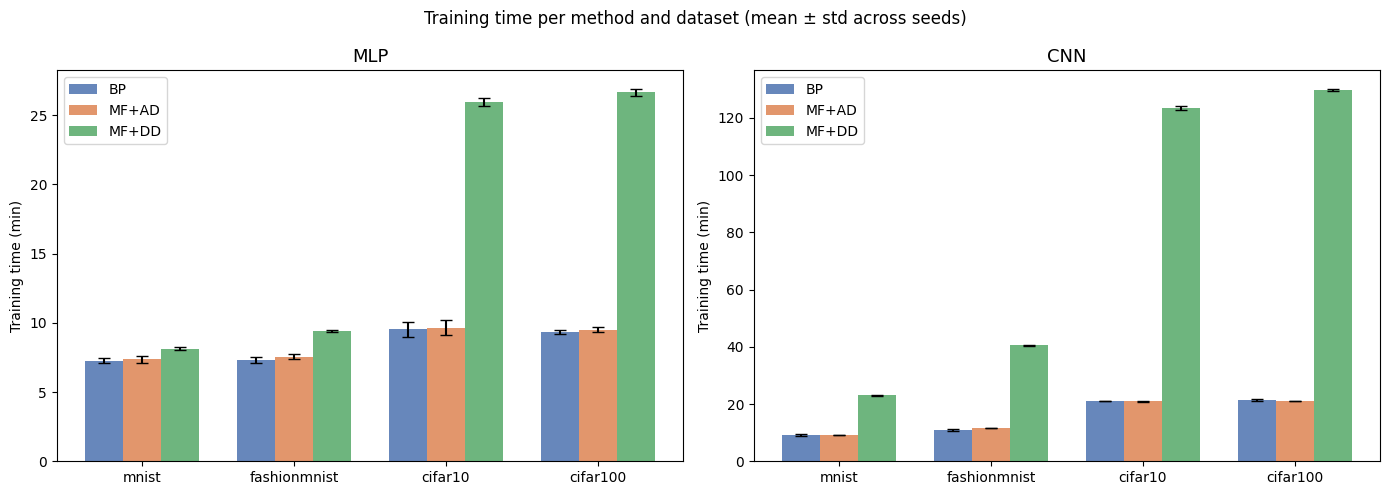

In [ ]:
METHOD_ORDER = ["bp", "mf_ad", "mf_dd"]
METHOD_LABELS = {"bp": "BP", "mf_ad": "MF+AD", "mf_dd": "MF+DD"}
COLORS = {"bp": "#4C72B0", "mf_ad": "#DD8452", "mf_dd": "#55A868"}

fig, axes = plt.subplots(1, 2, figsize=(14, 5), sharey=False)

for ax, arch in zip(axes, ["mlp", "cnn"]):
    x = np.arange(len(DATASETS))
    width = 0.25
    for i, method in enumerate(METHOD_ORDER):
        means, stds = [], []
        for ds in DATASETS:
            m, s = get_time(arch, method, ds)
            means.append(m)
            stds.append(s)
        ax.bar(
            x + i * width,
            means,
            width,
            yerr=stds,
            label=METHOD_LABELS[method],
            color=COLORS[method],
            capsize=4,
            alpha=0.85,
        )

    ax.set_title(arch.upper(), fontsize=13)
    ax.set_xticks(x + width)
    ax.set_xticklabels(DATASETS)
    ax.set_ylabel("Training time (min)")
    ax.legend()

fig.suptitle("Training time per method and dataset (mean \u00b1 std across seeds)", fontsize=12)
plt.tight_layout()
plt.show()